In [1]:
%matplotlib inline
from pynq import Overlay, allocate
import ipywidgets as widgets
from IPython.display import display
from IPython.display import clear_output
import numpy as np
import matplotlib.pyplot as plt
import time

# 1. Load the new design
ol = Overlay("/home/xilinx/jupyter_notebooks/muon_project_16/design_1.bit")

# 2. Map the DMA and the new GPIO block
dma = ol.axi_dma_0
trigger_gpio = ol.axi_gpio_0 # Name matches your block design

# 3. Simple Write Command (Sets threshold to 1240)
# Channel 1 is the default output port for the AXI GPIO
def set_threshold(num):
    value = int(num*4095/3.3)
    trigger_gpio.channel1.write(value, 0xFFFFFFFF)
    print(f"Threshold updated to", value, "!")

set_threshold(1.2)

# ==========================================================
# BONUS: Interactive Jupyter Slider
# Run this cell, and a slider will appear. 
# As you drag it, it instantly updates the FPGA hardware!
# ==========================================================

#def update_threshold(change):
#   new_val = change['new']
#    trigger_gpio.channel1.write(new_val, 0xFFFFFFFF)

# Create a slider from 0 to 4095 (12-bit max)
#threshold_slider = widgets.IntSlider(
#    value=1240,
#    min=0,
#    max=4095,
#    step=10,
#    description='Threshold:',
#    continuous_update=True
#)

#threshold_slider.observe(update_threshold, names='value')
#display(threshold_slider)

Threshold updated to 1489 !


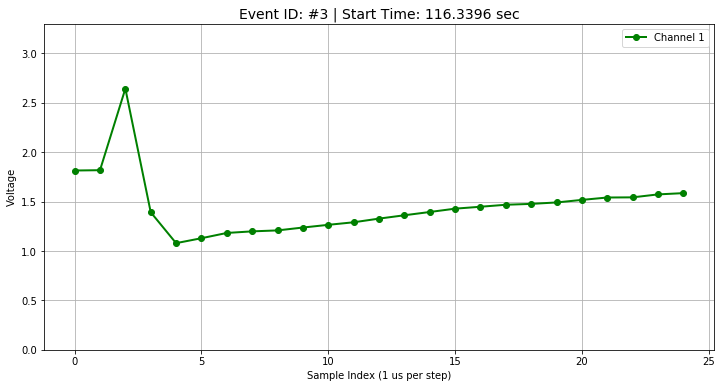

Test Stopped.


In [2]:
# 2. Allocate the 256-bit Buffer
# 1 Sample = 256 bits = 32 Bytes
# Packet Size = 25 Samples
PACKET_SIZE = 25
BYTES_PER_SAMPLE = 32

# We allocate an array of raw bytes for easy slicing
input_buffer = allocate(shape=(PACKET_SIZE * BYTES_PER_SAMPLE,), dtype=np.uint8)

print("16-Channel Mega-Trigger Ready. Waiting for pulses...")

try:
    while True:
        # A. Queue Transfer
        dma.recvchannel.transfer(input_buffer)
        
        # B. Robust Polling (Wait for trigger)
        wait_start = time.time()
        #timeout = False
        while (dma.read(0x34) & 0x02) == 0:
            pass

        # C. Process Data
        input_buffer.invalidate()
        raw_bytes = bytes(input_buffer) # Convert to standard Python bytes
        
        # Arrays to hold the parsed data for plotting
        ch1_wave = []
        #ch2_wave = []
        timestamps = []
        
        packet_event_id = 0
        
        # D. Decode the 256-bit words
        for i in range(PACKET_SIZE):
            # Slice 32 bytes for the current sample
            start_idx = i * 32
            sample_bytes = raw_bytes[start_idx : start_idx + 32]
            
            # The Zynq processor is Little-Endian.
            # Bytes [0:24]   = 192 bits of ADC Data (Ch1 to Ch16)
            # Bytes [24:28]  = 32 bits Event ID
            # Bytes [28:32]  = 32 bits Timestamp
            
            adc_data_bytes = sample_bytes[0:24]
            event_id_bytes = sample_bytes[24:28]
            timestamp_bytes = sample_bytes[28:32]
            
            # Convert bytes to integers
            adc_block = int.from_bytes(adc_data_bytes, byteorder='little')
            event_id = int.from_bytes(event_id_bytes, byteorder='little')
            timestamp = int.from_bytes(timestamp_bytes, byteorder='little')
            
            # Extract 12-bit Channels from the 192-bit block
            # Ch1 is at the very bottom (shift 0), Ch2 is shift 12, etc.
            ch1_val = ((adc_block >> (0 * 12)) & 0xFFF)*3.3/4095
            #ch2_val = (adc_block >> (1 * 12)) & 0xFFF
            # If you wired Ch16, it would be: (adc_block >> (15 * 12)) & 0xFFF
            
            ch1_wave.append(ch1_val)
            #ch2_wave.append(ch2_val)
            timestamps.append(timestamp)
            
            # The Event ID should be the same for all 20 samples in a packet
            if i == 0: packet_event_id = event_id

        # E. Visualization
        clear_output(wait=True)
        plt.figure(figsize=(12, 6))
        
        plt.plot(ch1_wave, 'g-o', label='Channel 1', linewidth=2)
        #plt.plot(ch2_wave, 'b--x', label='Channel 2', linewidth=2, alpha=0.7)
        
        # Show the metadata in the title!
        plt.title(f"Event ID: #{packet_event_id} | Start Time: {timestamps[0]/1000000:.4f} sec", fontsize=14)
        plt.xlabel("Sample Index (1 us per step)")
        plt.ylabel("Voltage")
        plt.ylim(0, 3.3)
        plt.legend()
        plt.grid(True)
        plt.show()

except KeyboardInterrupt:
    print("Test Stopped.")
    dma.recvchannel.stop()

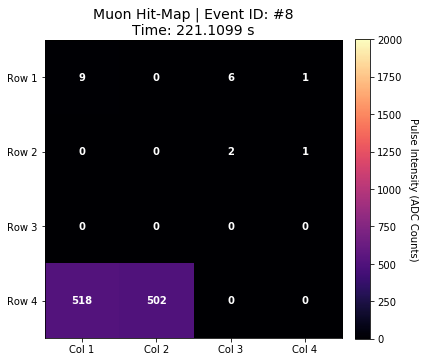

In [ ]:
%matplotlib inline
from pynq import Overlay, allocate
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# ======================================================================
# 1. HARDWARE SETUP
# ======================================================================
print("Loading FPGA Bitstream...")
ol = Overlay("/home/xilinx/jupyter_notebooks/muon_project_16/design_1.bit")
dma = ol.axi_dma_0

trigger_gpio = ol.axi_gpio_0 # Name matches your block design

# 3. Simple Write Command (Sets threshold to 1240)
# Channel 1 is the default output port for the AXI GPIO
def set_threshold(num):
    value = int(num*4095/3.3)
    trigger_gpio.channel1.write(value, 0xFFFFFFFF)
    print(f"Threshold updated to", value,"!")

set_threshold(1.2)

# 1 Sample = 256 bits = 32 Bytes | Packet Size = 20 Samples
PACKET_SIZE = 25
BYTES_PER_SAMPLE = 32
input_buffer = allocate(shape=(PACKET_SIZE * BYTES_PER_SAMPLE,), dtype=np.uint8)

# --- DECIMATION SETTING ---
# Update the visual grid every N events to keep the loop fast
PLOT_EVERY_N = 5  

print(f"16-Channel 4x4 Heat-Map Ready. Waiting for muons...")

# ======================================================================
# 2. MAIN ACQUISITION LOOP
# ======================================================================
try:
    packet_count = 0
    
    while True:
        # A. Queue the DMA Transfer
        dma.recvchannel.transfer(input_buffer)
        
        # B. Simple Polling (Wait patiently for the hardware trigger)
        while (dma.read(0x34) & 0x02) == 0:
            pass 

        # C. Process the Data
        input_buffer.invalidate()
        raw_bytes = bytes(input_buffer)
        
        # Create a 2D numpy array to hold the raw waveform: 20 rows (time), 16 cols (channels)
        event_data = np.zeros((PACKET_SIZE, 16), dtype=np.int32)
        packet_event_id = 0
        packet_timestamp = 0
        
        # D. Decode the 256-bit words into the 2D array
        for i in range(PACKET_SIZE):
            start_idx = i * 32
            sample_bytes = raw_bytes[start_idx : start_idx + 32]
            
            adc_data_bytes  = sample_bytes[0:24]
            event_id_bytes  = sample_bytes[24:28]
            timestamp_bytes = sample_bytes[28:32]
            
            adc_block = int.from_bytes(adc_data_bytes, byteorder='little')
            
            if i == 0:
                packet_event_id  = int.from_bytes(event_id_bytes, byteorder='little')
                packet_timestamp = int.from_bytes(timestamp_bytes, byteorder='little')
            
            # Extract all 16 channels using bit-shifting
            for ch in range(16):
                event_data[i, ch] = (adc_block >> (ch * 12)) & 0xFFF

        packet_count += 1
        
        # ======================================================================
        # E. THE HEAT-MAP MATH
        # ======================================================================
        # 1. Find the absolute minimum value (the pulse peak) for all 16 channels
        channel_mins = np.min(event_data, axis=0)
        
        # 2. Find the baseline. Since sample 0 is pre-trigger, it is a perfect baseline!
        baselines = event_data[0, :]
        
        # 3. Calculate Flash Intensity (Baseline - Peak)
        # A deeper negative pulse creates a larger positive intensity number
        intensities = baselines - channel_mins
        
        # 4. Filter out tiny background noise fluctuations (clip negatives to 0)
        intensities = np.clip(intensities, 0, None)
        
        # 5. Reshape the 16 flat channels into a 4x4 physical grid
        # Adjust the order here if your SiPMs are wired differently physically
        hit_grid = intensities.reshape((4, 4))
        
        # ======================================================================
        # F. VISUALIZATION
        # ======================================================================
        
        clear_output(wait=True)
            
        # Create a square figure for the grid
        fig, ax = plt.subplots(figsize=(6, 6))
            
        # Draw the 4x4 Heatmap. 
        # vmax locks the color scale maximum (adjust this based on your max expected pulse height)
        im = ax.imshow(hit_grid, cmap='magma', vmin=0, vmax=2000)
        
        # Add a colorbar to show the intensity scale
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Pulse Intensity (ADC Counts)', rotation=270, labelpad=15)
            
        # Add text labels inside each rectangle showing the exact intensity number
        for row in range(4):
            for col in range(4):
                val = int(hit_grid[row, col])
                # If it's a bright flash, use black text. If dark, use white text.
                text_color = "black" if val > 750 else "white"
                ax.text(col, row, str(val), ha="center", va="center", color=text_color, fontweight='bold')
            
        # Formatting
        time_sec = packet_timestamp / 1000000.0
        ax.set_title(f"Muon Hit-Map | Event ID: #{packet_event_id}\nTime: {time_sec:.4f} s", fontsize=14)
        ax.set_xticks([0, 1, 2, 3])            
        ax.set_yticks([0, 1, 2, 3])
        ax.set_xticklabels(['Col 1', 'Col 2', 'Col 3', 'Col 4'])
        ax.set_yticklabels(['Row 1', 'Row 2', 'Row 3', 'Row 4'])
            
        plt.tight_layout()
        plt.show()
        plt.close()

except KeyboardInterrupt:
    print(f"DAQ Stopped safely. Total hardware events captured: {packet_count}")
    dma.recvchannel.stop()

In [2]:
import numpy as np

def calculate_muon_trajectory(intensities, noise_threshold=50):
    """
    Takes a 16-element array of pulse intensities (Baseline - Peak)
    and returns the estimated 2D angle and Z-depth range.
    """
    # 1. Input Validation & Reshaping
    # Ensure it's a flat 16-element array and filter noise
    intensities = np.array(intensities).flatten()
    intensities[intensities < noise_threshold] = 0
    
    if np.max(intensities) == 0:
        return None, "No Event"

    # 2. Find the Epicenter
    max_idx = int(np.argmax(intensities))
    i_max, j_max = max_idx // 4, max_idx % 4
    I_max = intensities[max_idx]

    # 3. Find the Neighbors
    neighbors = []
    neighbor_intensities = []
    
    for di in [-1, 0, 1]:
        for dj in [-1, 0, 1]:
            ni, nj = i_max + di, j_max + dj
            # Check bounds and exclude the center pixel itself
            if 0 <= ni < 4 and 0 <= nj < 4 and not (di == 0 and dj == 0):
                n_idx = ni * 4 + nj
                neighbors.append(n_idx)
                neighbor_intensities.append(intensities[n_idx])
                
    if sum(neighbor_intensities) == 0:
        return 0.0, ">30 mm" # Direct hit, no splash
        
    # 4. Calculate Z-Depth Range (Inverse Square Law)
    I_mean = sum(neighbor_intensities) / len(neighbor_intensities)
    ratio = I_max / (I_mean + 1e-6) # Add tiny number to prevent divide-by-zero
    
    if ratio > 8:
        z_range = "0–3 mm"
    elif ratio > 4:
        z_range = "3–10 mm"
    elif ratio > 2:
        z_range = "10–30 mm"
    else:
        z_range = ">30 mm"

    # 5. Calculate 2D Angle (Centroid Vector Math)
    # Sort neighbors by intensity to find the two brightest
    sorted_neighbors = sorted(zip(neighbors, neighbor_intensities), key=lambda x: x[1], reverse=True)
    
    vec_total = np.array([0.0, 0.0])
    
    # Sum ALL valid neighbors to find the true centroid of the splash
    for n_idx, I_n in sorted_neighbors:
        if I_n == 0: continue
        i_n, j_n = n_idx // 4, n_idx % 4
        # Vector from center to neighbor
        vec = np.array([i_n - i_max, j_n - j_max], dtype=float)
        weight = np.sqrt(I_n)
        vec_total += weight * vec
        
    norm = np.linalg.norm(vec_total)
    if norm < 1e-12:
        angle = 0.0
    else:
        direction = vec_total / norm
        angle = np.degrees(np.arctan2(direction[1], direction[0]))

    return angle, z_range

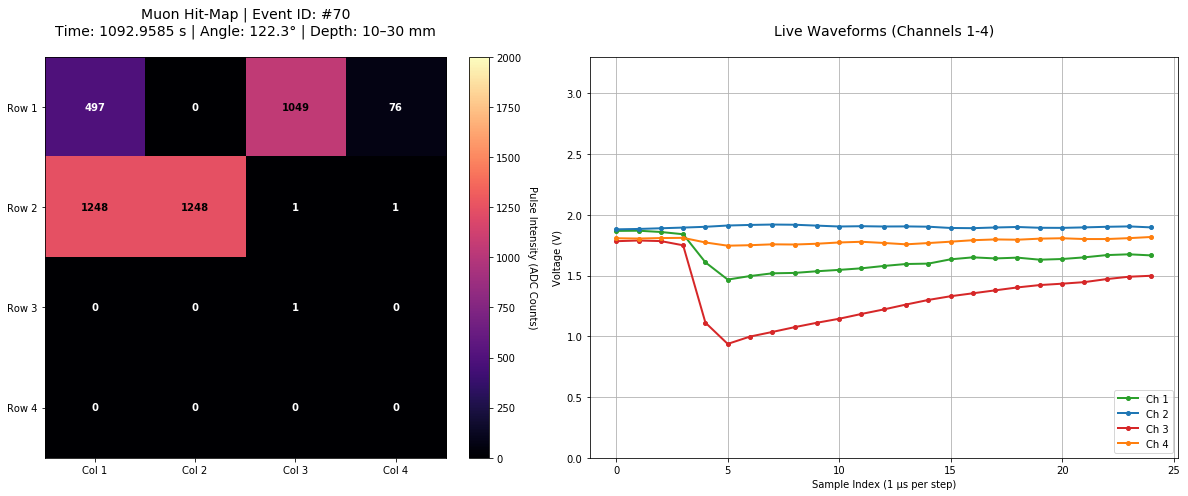

In [ ]:
%matplotlib inline
from pynq import Overlay, allocate
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# ======================================================================
# 1. HARDWARE SETUP
# ======================================================================
print("Loading FPGA Bitstream...")
ol = Overlay("/home/xilinx/jupyter_notebooks/muon_project_4/design_1.bit")
dma = ol.axi_dma_0

trigger_gpio = ol.axi_gpio_0 # Name matches your block design

# 3. Simple Write Command (Sets threshold to 1240)
# Channel 1 is the default output port for the AXI GPIO
def set_threshold(num):
    value = int(num*4095/3.3)
    trigger_gpio.channel1.write(value, 0xFFFFFFFF)
    print(f"Threshold updated to",value,"!")

set_threshold(1.2)

# ======================================================================
# 2. CONFIGURATION
# ======================================================================
# 1 Sample = 256 bits = 32 Bytes
# Packet Size = 25 Samples
PACKET_SIZE = 25
BYTES_PER_SAMPLE = 32

# Buffer allocated as raw bytes to easily slice the 256-bit words
input_buffer = allocate(shape=(PACKET_SIZE * BYTES_PER_SAMPLE,), dtype=np.uint8)

# --- DECIMATION SETTING ---
# Update the visual grid every N events to keep the loop fast
# If your generator is 10 Hz, plotting every 5th event gives 2 FPS.
PLOT_EVERY_N = 1  

print(f"16-Channel 4x4 Heat-Map Ready. Waiting for muons...")

# ======================================================================
# 3. MAIN ACQUISITION LOOP
# ======================================================================
try:
    packet_count = 0
    
    while True:
        # A. Queue the DMA Transfer
        dma.recvchannel.transfer(input_buffer)
        
        # B. Simple Polling (Wait patiently for the hardware trigger)
        # We removed the 2.0 second timeout. It will now wait forever
        # without breaking the AXI stream alignment.
        while (dma.read(0x34) & 0x02) == 0:
            pass 

        # C. Process the Data
        input_buffer.invalidate()
        raw_bytes = bytes(input_buffer)
        
        # Create a 2D numpy array to hold the raw waveform: 20 rows (time), 16 cols (channels)
        event_data = np.zeros((PACKET_SIZE, 16), dtype=np.int32)
        packet_event_id = 0
        packet_timestamp = 0
        
        # D. Decode the 256-bit words into the 2D array
        # This loop is the "translator" between the raw, messy electrical signals
        # and the neat, organized math matrices that Python loves.
        for i in range(PACKET_SIZE):
            start_idx = i * 32
            sample_bytes = raw_bytes[start_idx : start_idx + 32]
            
            # Slice the 32-byte chunk into the three physical segments
            # we designed in the VHDL (RECORDING state).
            adc_data_bytes  = sample_bytes[0:24]
            event_id_bytes  = sample_bytes[24:28]
            timestamp_bytes = sample_bytes[28:32]
            
            # Convert raw bytes to Python integers using 'little-endian' byteorder.
            adc_block = int.from_bytes(adc_data_bytes, byteorder='little')
            
            # Grab the Metadata (Event ID and Timestamp) just once per packet.
            if i == 0:
                packet_event_id  = int.from_bytes(event_id_bytes, byteorder='little')
                packet_timestamp = int.from_bytes(timestamp_bytes, byteorder='little')
            
            # Extract all 16 channels using bit-shifting and a mask.
            for ch in range(16):
                event_data[i, ch] = (adc_block >> (ch * 12)) & 0xFFF

        # Successfully captured an event! Increment our master counter.
        packet_count += 1
        
        # ======================================================================
        # E. THE HEAT-MAP MATH
        # ======================================================================
        # 1. Find the absolute minimum value (the pulse peak) for all 16 channels
        # Since SiPM pulses are negative-going, this is the perfect way to find the flash.
        channel_mins = np.min(event_data, axis=0)
        
        # 2. Find the baseline. Since sample 0 is pre-trigger, it is a perfect baseline!
        baselines = event_data[0, :]
        
        # 3. Calculate Flash Intensity (Baseline - Peak)
        # A deeper negative pulse creates a larger positive intensity number.
        intensities = baselines - channel_mins
        
        # 4. Filter out tiny background noise fluctuations (clip negatives to 0).
        intensities = np.clip(intensities, 0, None)
        
        # --- NEW: RUN THE MATH MODEL ---
        angle, z_range = calculate_muon_trajectory(intensities)
        
        # 5. Reshape the 16 flat channels into a 4x4 physical grid.
        # This maps Channel 0 to the top-left, and Channel 15 to the bottom-right.
        hit_grid = intensities.reshape((4, 4))
        
        # ======================================================================
        # F. DECIMATED VISUALIZATION
        # ======================================================================
        # Only waste time drawing the graphs if it is the Nth event.
        if packet_count % PLOT_EVERY_N == 0:
            
            clear_output(wait=True)
            
            # Create a 2-part figure with two subplots: one for the 16-channel hit-map,
            # and another for the live channel 1 waveform.
            fig, (ax_grid, ax_plot) = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [1, 1]})
            
            # --- Draw the 4x4 Heatmap (Hit-Map) ---
            # Using 'magma' color map, it idles at black and flares up to bright yellow/white.
            # adjusting 'vmax' (color scale maximum) based on max expected pulse height.
            im = ax_grid.imshow(hit_grid, cmap='magma', vmin=0, vmax=2000)
            
            # Add a colorbar to show the intensity scale.
            cbar = fig.colorbar(im, ax=ax_grid, fraction=0.046, pad=0.04)
            cbar.set_label('Pulse Intensity (ADC Counts)', rotation=270, labelpad=15)
            
            # Add text labels inside each rectangle showing the exact intensity number.
            for row in range(4):
                for col in range(4):
                    val = int(hit_grid[row, col])
                    # If it's a bright flash, use black text. If dark, use white text.
                    text_color = "black" if val > 750 else "white"
                    ax_grid.text(col, row, str(val), ha="center", va="center", color=text_color, fontweight='bold')
            
            # Update title to show the new calculated physics data
            time_sec = packet_timestamp / 1000000.0
            angle_text = f"{angle:.1f}°" if angle is not None else "N/A"
            title_text = (f"Muon Hit-Map | Event ID: #{packet_event_id}\n"
                          f"Time: {time_sec:.4f} s | Angle: {angle_text} | Depth: {z_range}\n")
            ax_grid.set_title(title_text, fontsize=14)
            
            ax_grid.set_xticks([0, 1, 2, 3])
            ax_grid.set_yticks([0, 1, 2, 3])
            ax_grid.set_xticklabels(['Col 1', 'Col 2', 'Col 3', 'Col 4'])
            ax_grid.set_yticklabels(['Row 1', 'Row 2', 'Row 3', 'Row 4'])
            
            # --- 2. Draw the First 4 Channels ---
            # Loop through the first 4 columns and plot them on the same axis
            colors = ['#2ca02c', '#1f77b4', '#d62728', '#ff7f0e'] # Green, Blue, Red, Orange
            for ch in range(4):
                ax_plot.plot(event_data[:, ch]*3.3/4095, color=colors[ch], marker='o', markersize=4, label=f'Ch {ch+1}', linewidth=2)
            
            ax_plot.set_title(f"Live Waveforms (Channels 1-4)\n", fontsize=14)
            ax_plot.set_xlabel("Sample Index (1 μs per step)")
            ax_plot.set_ylabel("Voltage (V)")
            ax_plot.set_ylim(0, 3.3) 
            ax_plot.legend(loc='lower right') # Moved legend so it doesn't cover high baseline traces
            ax_plot.grid(True)
            
            plt.tight_layout()
            plt.show()
            plt.close()

except KeyboardInterrupt:
    print(f"DAQ Stopped safely. Total hardware events captured: {packet_count}")
    dma.recvchannel.stop()

DAQ Stopped safely. Total hardware events captured: 69


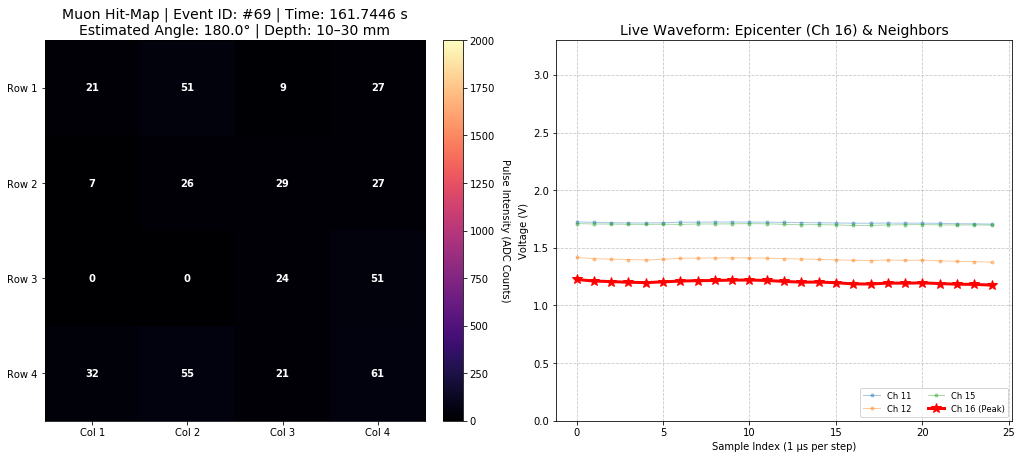

In [1]:
%matplotlib inline
from pynq import Overlay, allocate
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time


# ======================================================================
# 1. THE MATH MODEL
# ======================================================================
def calculate_muon_trajectory(intensities, noise_threshold=50):
    intensities = np.array(intensities).flatten()
    intensities[intensities < noise_threshold] = 0
    
    if np.max(intensities) == 0:
        return None, "No Event"

    max_idx = int(np.argmax(intensities))
    i_max, j_max = max_idx // 4, max_idx % 4
    I_max = intensities[max_idx]

    neighbors = []
    neighbor_intensities = []
    
    for di in [-1, 0, 1]:
        for dj in [-1, 0, 1]:
            ni, nj = i_max + di, j_max + dj
            if 0 <= ni < 4 and 0 <= nj < 4 and not (di == 0 and dj == 0):
                n_idx = ni * 4 + nj
                neighbors.append(n_idx)
                neighbor_intensities.append(intensities[n_idx])
                
    if sum(neighbor_intensities) == 0:
        return 0.0, ">30 mm"
        
    I_mean = sum(neighbor_intensities) / len(neighbor_intensities)
    ratio = I_max / (I_mean + 1e-6)
    
    if ratio > 8: z_range = "0–3 mm"
    elif ratio > 4: z_range = "3–10 mm"
    elif ratio > 2: z_range = "10–30 mm"
    else: z_range = ">30 mm"

    sorted_neighbors = sorted(zip(neighbors, neighbor_intensities), key=lambda x: x[1], reverse=True)
    vec_total = np.array([0.0, 0.0])
    
    for n_idx, I_n in sorted_neighbors:
        if I_n == 0: continue
        i_n, j_n = n_idx // 4, n_idx % 4
        vec = np.array([i_n - i_max, j_n - j_max], dtype=float)
        weight = np.sqrt(I_n)
        vec_total += weight * vec
        
    norm = np.linalg.norm(vec_total)
    if norm < 1e-12:
        angle = 0.0
    else:
        direction = vec_total / norm
        angle = np.degrees(np.arctan2(direction[1], direction[0]))

    return angle, z_range

# ======================================================================
# 2. HARDWARE SETUP
# ======================================================================
print("Loading FPGA Bitstream...")
ol = Overlay("/home/xilinx/jupyter_notebooks/muon_project_16_final/design_1.bit")
dma = ol.axi_dma_0

trigger_gpio = ol.axi_gpio_0 # Name matches your block design

# 3. Simple Write Command (Sets threshold to 1240)
# Channel 1 is the default output port for the AXI GPIO
def set_threshold(num):
    value = int(num*4095/3.3)
    trigger_gpio.channel1.write(value, 0xFFFFFFFF)
    print(f"Threshold updated to",value,"!")

set_threshold(1.2)

PACKET_SIZE = 25
BYTES_PER_SAMPLE = 32
input_buffer = allocate(shape=(PACKET_SIZE * BYTES_PER_SAMPLE,), dtype=np.uint8)

PLOT_EVERY_N = 1 
print(f"Dynamic Epicenter Tracking Ready. Waiting for muons...")

# ======================================================================
# 3. MAIN ACQUISITION LOOP
# ======================================================================
try:
    packet_count = 0
    
    while True:
        dma.recvchannel.transfer(input_buffer)
        
        while (dma.read(0x34) & 0x02) == 0:
            pass 

        input_buffer.invalidate()
        raw_bytes = bytes(input_buffer)
        
        event_data = np.zeros((PACKET_SIZE, 16), dtype=np.int32)
        packet_event_id = 0
        packet_timestamp = 0
        
        for i in range(PACKET_SIZE):
            start_idx = i * 32
            sample_bytes = raw_bytes[start_idx : start_idx + 32]
            
            adc_data_bytes  = sample_bytes[0:24]
            event_id_bytes  = sample_bytes[24:28]
            timestamp_bytes = sample_bytes[28:32]
            
            adc_block = int.from_bytes(adc_data_bytes, byteorder='little')
            
            if i == 0:
                packet_event_id  = int.from_bytes(event_id_bytes, byteorder='little')
                packet_timestamp = int.from_bytes(timestamp_bytes, byteorder='little')
            
            for ch in range(16):
                event_data[i, ch] = (adc_block >> (ch * 12)) & 0xFFF

        packet_count += 1
        
        # --- MATH & PROCESSING ---
        channel_mins = np.min(event_data, axis=0)
        baselines = event_data[0, :]
        intensities = baselines - channel_mins
        
        calc_angle, calc_z = calculate_muon_trajectory(intensities)
        
        intensities = np.clip(intensities, 0, None)
        hit_grid = intensities.reshape((4, 4))
        
        # --- DYNAMIC EPICENTER LOGIC ---
        # 1. Find the absolute brightest channel
        max_idx = int(np.argmax(intensities))
        i_max, j_max = max_idx // 4, max_idx % 4
        
        # 2. Gather its immediate physical neighbors
        active_channels = []
        for di in [-1, 0, 1]:
            for dj in [-1, 0, 1]:
                ni, nj = i_max + di, j_max + dj
                if 0 <= ni < 4 and 0 <= nj < 4:
                    active_channels.append(ni * 4 + nj)
        
        # --- VISUALIZATION ---
        if packet_count % PLOT_EVERY_N == 0:
            clear_output(wait=True)
            
            fig, (ax_grid, ax_plot) = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [1, 1]})
            
            # --- The Heatmap ---
            im = ax_grid.imshow(hit_grid, cmap='magma', vmin=0, vmax=2000)
            cbar = fig.colorbar(im, ax=ax_grid, fraction=0.046, pad=0.04)
            cbar.set_label('Pulse Intensity (ADC Counts)', rotation=270, labelpad=15)
            
            for row in range(4):
                for col in range(4):
                    val = int(hit_grid[row, col])
                    text_color = "black" if val > 750 else "white"
                    ax_grid.text(col, row, str(val), ha="center", va="center", color=text_color, fontweight='bold')
            
            time_sec = packet_timestamp / 1000000.0
            
            title_text = f"Muon Hit-Map | Event ID: #{packet_event_id} | Time: {time_sec:.4f} s\n"
            if calc_angle is not None:
                title_text += f"Estimated Angle: {calc_angle:.1f}° | Depth: {calc_z}"
            else:
                title_text += f"Status: {calc_z}"
                
            ax_grid.set_title(title_text, fontsize=14)
            ax_grid.set_xticks([0, 1, 2, 3])
            ax_grid.set_yticks([0, 1, 2, 3])
            ax_grid.set_xticklabels(['Col 1', 'Col 2', 'Col 3', 'Col 4'])
            ax_grid.set_yticklabels(['Row 1', 'Row 2', 'Row 3', 'Row 4'])
            
            # --- The Dynamic Waveform Plot ---
            for ch in active_channels:
                if ch == max_idx:
                    # Make the epicenter stand out with a bold red line and star marker
                    ax_plot.plot(event_data[:, ch]*3.3/4095, marker='*', color='red', label=f'Ch {ch+1} (Peak)', linewidth=3, markersize=10, zorder=10)
                else:
                    # Make the neighboring splash channels faint to reduce visual clutter
                    ax_plot.plot(event_data[:, ch]*3.3/4095, marker='.', alpha=0.4, label=f'Ch {ch+1}', linewidth=1)
            
            ax_plot.set_title(f"Live Waveform: Epicenter (Ch {max_idx+1}) & Neighbors", fontsize=14)
            ax_plot.set_xlabel("Sample Index (1 μs per step)")
            ax_plot.set_ylabel("Voltage (V)")
            ax_plot.set_ylim(0, 3.3) 
            
            # Organize the legend into 2 columns if there are many neighbors
            ax_plot.legend(loc='lower right', fontsize='small', ncol=2) 
            ax_plot.grid(True, linestyle='--', alpha=0.7)
            
            plt.tight_layout()
            plt.show()
            plt.close()

except KeyboardInterrupt:
    print(f"DAQ Stopped safely. Total hardware events captured: {packet_count}")
    dma.recvchannel.stop()